LINK VIDEO GOOGLE DRIVE : https://drive.google.com/file/d/116FT6qM2nxYoB2-sK-zve2_uc0lwkUpV/view?usp=drive_link

### NO 1 A

In [20]:
import pandas as pd
import numpy as np

# Load features dan target
df_features = pd.read_csv('A.csv')
df_target = pd.read_csv('A_targets.csv')

# Gabungkan dataset
df = pd.concat([df_features, df_target], axis=1)

# Cek shape
print("Shape data:", df.shape)

# Preview data
df.head()

Shape data: (5000, 26)


,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,Student_ID,placement_status,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,6.5,8,Yes,Medium,Tier 2,Yes,Medium,1,Placed,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,7.1,8,Yes,Medium,Tier 3,Yes,Low,2,Placed,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,6.1,2,No,Low,Tier 2,Yes,High,3,Placed,17.73
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,7.3,7,No,Medium,Tier 1,Yes,Low,4,Placed,14.52
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,6.0,7,No,Medium,Tier 1,Yes,Medium,5,Placed,15.91


Dataset terdiri dari 5000 data dan 26 fitur. dengan target yaitu placement_status (klasifikasi) dan salary_lpa (regresi)

In [21]:
# Info dataset
df.info()

# Statistik deskriptif
df.describe()

# Cek distribusi target klasifikasi
print(df['placement_status'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   5000 non-null   int64  
 1   gender                       5000 non-null   str    
 2   branch                       5000 non-null   str    
 3   cgpa                         5000 non-null   float64
 4   tenth_percentage             5000 non-null   float64
 5   twelfth_percentage           5000 non-null   float64
 6   backlogs                     5000 non-null   int64  
 7   study_hours_per_day          5000 non-null   float64
 8   attendance_percentage        5000 non-null   float64
 9   projects_completed           5000 non-null   int64  
 10  internships_completed        5000 non-null   int64  
 11  coding_skill_rating          5000 non-null   int64  
 12  communication_skill_rating   5000 non-null   int64  
 13  aptitude_skill_rating        

distribusi target klasifikasinya adalah placed : 4303 (86%) dan not placed : 697 (14%). Datasetnya imbalanced sehingga model jadi lebih mudah prediksi kelas "placed"

In [22]:
# Cek missing values
missing = df.isnull().sum()
print(missing[missing > 0])

extracurricular_involvement    1006
dtype: int64


terdapat missing value pada extracurricular_involvement (1006), karena ini adalah variabel kategorikal, maka penanganan missing valuenya adalah diisi menggunakan modus/mode.
 

In [23]:
# Categorical isi dengan modus
mode_value = df['extracurricular_involvement'].mode()[0]
df['extracurricular_involvement'] = df['extracurricular_involvement'].fillna(mode_value)

In [24]:
# Cek missing values
missing = df.isnull().sum()
print(missing[missing > 0])

Series([], dtype: int64)


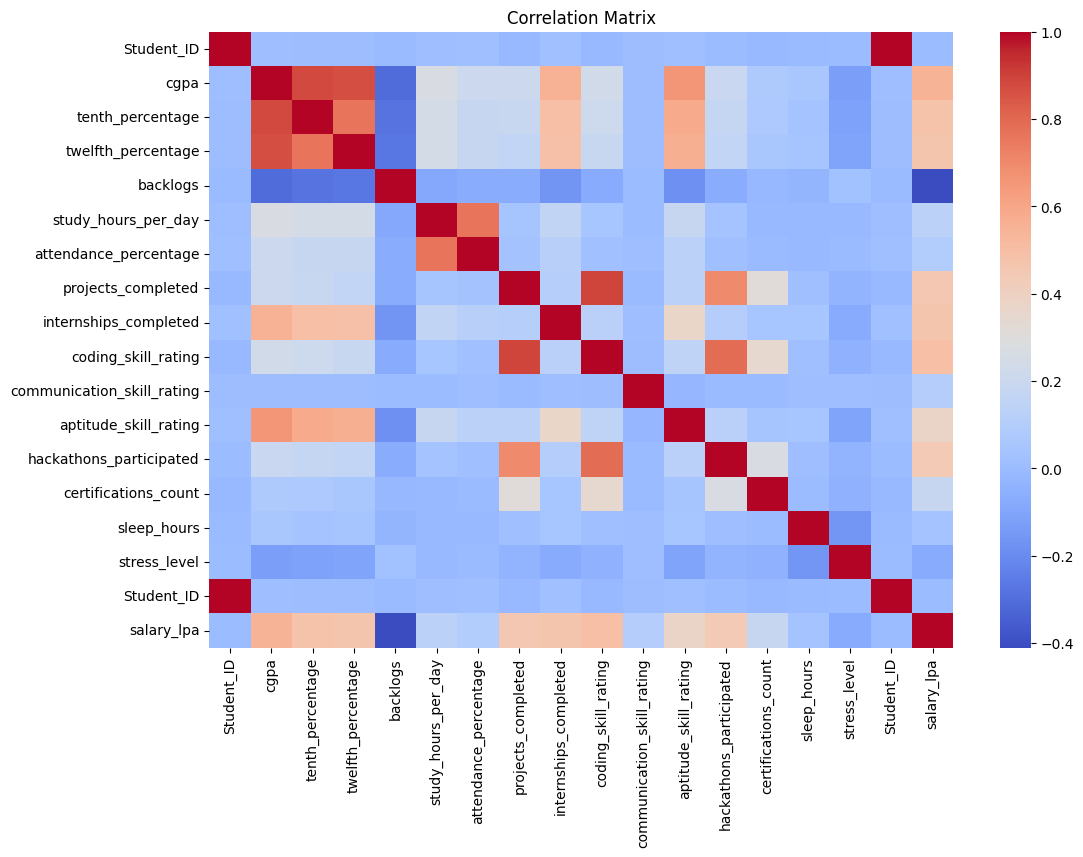

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df.drop(['placement_status','salary_lpa'], axis=1)

X_scaled = scaler.fit_transform(X)

In [29]:
y_class = df['placement_status']   # klasifikasi
y_reg = df['salary_lpa']       # regresi

In [30]:
from sklearn.model_selection import train_test_split

# Klasifikasi
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_scaled, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# Regresi
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42
)

### NO 1 B

In [31]:
# logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression()
lr.fit(X_train_c, y_train_c)

y_pred_lr = lr.predict(X_test_c)

acc_lr = accuracy_score(y_test_c, y_pred_lr)

print("Logistic Regression Accuracy:", acc_lr)
print(classification_report(y_test_c, y_pred_lr))

Logistic Regression Accuracy: 0.89
              precision    recall  f1-score   support

           0       0.66      0.43      0.52       139
           1       0.91      0.96      0.94       861

    accuracy                           0.89      1000
   macro avg       0.79      0.70      0.73      1000
weighted avg       0.88      0.89      0.88      1000



In [32]:
# SVM

from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train_c, y_train_c)

y_pred_svm = svm.predict(X_test_c)

acc_svm = accuracy_score(y_test_c, y_pred_svm)

print("SVM Accuracy:", acc_svm)
print(classification_report(y_test_c, y_pred_svm))

SVM Accuracy: 0.892
              precision    recall  f1-score   support

           0       0.70      0.39      0.50       139
           1       0.91      0.97      0.94       861

    accuracy                           0.89      1000
   macro avg       0.80      0.68      0.72      1000
weighted avg       0.88      0.89      0.88      1000



In [33]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_c, y_train_c)

y_pred_rf = rf.predict(X_test_c)

acc_rf = accuracy_score(y_test_c, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)
print(classification_report(y_test_c, y_pred_rf))

Random Forest Accuracy: 0.887
              precision    recall  f1-score   support

           0       0.70      0.33      0.45       139
           1       0.90      0.98      0.94       861

    accuracy                           0.89      1000
   macro avg       0.80      0.65      0.69      1000
weighted avg       0.87      0.89      0.87      1000



In [34]:
# perbandingan model klasifikasi
import pandas as pd

results_clf = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Random Forest'],
    'Accuracy': [acc_lr, acc_svm, acc_rf]
}).sort_values(by='Accuracy', ascending=False)

results_clf

,Model,Accuracy
1,SVM,0.892
0,Logistic Regression,0.890
2,Random Forest,0.887


In [35]:
# Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr_reg = LinearRegression()
lr_reg.fit(X_train_r, y_train_r)

y_pred_lr_reg = lr_reg.predict(X_test_r)

rmse_lr = np.sqrt(mean_squared_error(y_test_r, y_pred_lr_reg))
r2_lr = r2_score(y_test_r, y_pred_lr_reg)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression RMSE: 4.087421013886826
Linear Regression R2: 0.5711756459389161


In [36]:
# Decision Tree

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_r, y_train_r)

y_pred_dt = dt.predict(X_test_r)

rmse_dt = np.sqrt(mean_squared_error(y_test_r, y_pred_dt))
r2_dt = r2_score(y_test_r, y_pred_dt)

print("Decision Tree RMSE:", rmse_dt)
print("Decision Tree R2:", r2_dt)

Decision Tree RMSE: 5.965502493503796
Decision Tree R2: 0.08657107814463205


In [37]:
# Random Forest

from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train_r, y_train_r)

y_pred_rf_reg = rf_reg.predict(X_test_r)

rmse_rf = np.sqrt(mean_squared_error(y_test_r, y_pred_rf_reg))
r2_rf = r2_score(y_test_r, y_pred_rf_reg)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)

Random Forest RMSE: 4.137153915348087
Random Forest R2: 0.56067688724164


In [38]:
# perbandingan model regresi

results_reg = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'RMSE': [rmse_lr, rmse_dt, rmse_rf],
    'R2': [r2_lr, r2_dt, r2_rf]
}).sort_values(by='R2', ascending=False)

results_reg

,Model,RMSE,R2
0,Linear Regression,4.087421,0.571176
2,Random Forest,4.137154,0.560677
1,Decision Tree,5.965502,0.086571


Seluruh fitur dalam dataset digunakan dalam proses pemodelan untuk mempertahankan informasi sebanyak mungkin dan memaksimalkan kualitas prediksi. hal tersebut dilakukan karena pada tahap awal tidak dilakukan feature selection, dengan tujuan untuk menghindari kehilangan informasi penting yang mungkin tidak terlihat secara langsung. Beberapa fitur memang terlihat kurang penting, tetapi fitur-fitur tersebut bisa menjadi penting ketika digabung dengan fitur lain. Oleh karena itu, penggunaan seluruh fitur lebih aman untuk menjaga informasi tetap utuh.

Pada klasifikasi, evaluasi model dilakukan menggunakan metrik akurasi. Dari tiga model yang dibandingkan, yaitu SVM, Logistic Regression, dan Random Forest, model Support Vector Machine (SVM) memberikan hasil terbaik dengan akurasi sebesar 0.8920. Model Logistic Regression berada dibawah SVM dengan akurasi 0.8902, sedangkan Random Forest sedikit lebih rendah dengan akurasi yaitu 0.8870. Selisih antara SVM dan Logistic Regression yang sangat kecil, yaitu sekitar 0.0018, menunjukkan bahwa struktur pola dalam data relatif tidak terlalu kompleks atau masih cukup linear, sehingga model sederhana seperti Logistic Regression juga mampu memberikan performa yang hampir setara dengan model yang lebih kompleks seperti SVM.

Pada regresi, evaluasi model dilakukan menggunakan RMSE dan R-square. Dari tiga model yang diuji, yaitu Linear Regression, Ridge Regression, dan Random Forest Regressor, model Linear Regression memberikan hasil terbaik dengan RMSE paling kecil yaitu 4.0874 serta nilai R-square tertinggi sebesar 0.5711. Nilai RMSE yang lebih rendah menunjukkan bahwa rata-rata kesalahan prediksi model ini lebih kecil dibandingkan model lainnya, sehingga prediksi yang dihasilkan lebih dekat dengan nilai aktual. Sementara itu, nilai R-square sebesar 0.5711 menunjukkan bahwa model mampu menjelaskan sekitar 57% variasi dalam data target. Meskipun angka ini belum sangat tinggi, namun sudah cukup baik untuk model regresi linear.